# Primary project: BID with scikit-learn ExtraTrees

A single robust weighted ExtraTrees regressor for 30-step return and price forecasting, with causal features, validation-based configuration selection and a zero-return baseline. This is one of the three original projects featured in the [README](../README.md). Original Vietnamese explanations, modeling logic, figures and saved outputs are retained.

## Saved result and scope

- Final test window: **MAPE 1.229%** (printed as 1.23%); zero-return baseline: **1.128%**.
- Mean across all three 30-observation test windows: **MAPE 3.706%**; baseline: **3.552%**. The model does not beat the baseline on average price MAPE.
- Mean daily direction accuracy is **38.889%**; mean composite selection loss is **0.968** versus baseline 1. These metrics answer different questions and do not establish trading profitability.
- Five configurations are checked on eight validation windows before three test windows. History had already been inspected in earlier experiments; a prospective evaluation remains necessary.

## Run

Use a separate environment with scikit-learn 1.8.0 (as pinned in the setup cell). Provide `data/raw/bid.csv` or set `BID_CSV`; the original Kaggle location is a fallback. The source notebook contains an embedded compressed CSV; this public copy removes that payload because redistribution rights are not documented. The loader reads the externally supplied original file and records its hash. Outputs now go to git-ignored `results/local/bid-extratrees/`. The root source notebook is unchanged. Read the [data card](../docs/data.md), [metric details](../docs/preliminary_results.md) and [evaluation designs](../docs/evaluation.md).


# BID — ExtraTrees có trọng số bền vững, 30 phiên

Một mô hình duy nhất. Kiểm tra 5 cấu hình trên 8 cửa sổ validation, gồm cấu hình cũ; cấu hình đã khóa mới được đánh giá trên 3 cửa sổ test. Test đã được xem trong những lần phát triển trước, nên kết quả là thăm dò và cần xác nhận trên dữ liệu mới.

Dữ liệu kèm kết thúc 24/09/2026, không phải dữ liệu mới nhất. Ngày dự báo bám ngày cuối CSV; ngày tương lai dự kiến T2–T6 trừ EXCLUDED_HOLIDAYS. Giữ biểu đồ có ngày/tháng/năm và bảng 30 phiên đầy đủ.

## Kết quả chạy trên dữ liệu kèm

Cấu hình chọn: {'train_window': 1512, 'min_leaf': 12, 'target_mode': 'joint', 'half_life': 252, 'robust_limit': 3.0}. Điểm validation: 0.8816, bản cũ 0,9023 (thấp hơn tốt hơn). MAPE validation 5.612%, bản cũ 5,682%.

MAPE test trung bình 3 cửa sổ: 3.706%, bản cũ 3,999%, đối chứng giữ giá 3.552%. MAPE 30 quan sát cuối: 1.229%, bản cũ 1.493%. Đúng chiều trên 90 phiên: 38.89%. Đọc cả sai số giá và đúng chiều; cải thiện một chỉ số không đảm bảo bắt được nhịp giao dịch.

Thử nghiệm validation trong lần nâng cấp: 8 cấu hình HistGradientBoosting (điểm tốt nhất 0,9571), 6 cấu hình Ridge (0,9116), 4 cấu hình ExtraTrees robust (0,8816). Bản cũ 0,9023. Chỉ ExtraTrees robust được chọn để chạy test; không trộn các mô hình.

Giới hạn: MAPE trung bình vẫn cao hơn đối chứng giữ giá 3,552%; đúng chiều không cải thiện so với bản cũ (38,89%). Dự báo tương lai vẫn chủ yếu tăng, chưa có bằng chứng bắt được dao động hàng ngày.


In [1]:
# 1. CÀI ĐẶT
import sys, subprocess
subprocess.check_call([sys.executable,'-m','pip','install','-q',
                      'scikit-learn==1.8.0','pandas','numpy','matplotlib','ipython'])
print('Cài xong. Nếu cập nhật package đã import, restart kernel rồi Run All.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.0 MB/s eta 0:00:00
Cài xong. Nếu cập nhật package đã import, restart kernel rồi Run All.


In [17]:
# 2. CẤU HÌNH
import io, json, hashlib, warnings, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

_repo_candidates = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next((p for p in _repo_candidates if (p / 'configs' / 'protocol.json').is_file()), Path.cwd())
_kaggle_file = Path('/kaggle/input/datasets/thescientist101/vn30-dailydata/Bank for Investment and Development Stock Price History.csv')
_csv_override = os.environ.get('BID_CSV')
CSV_FILE = Path(_csv_override) if _csv_override else REPO_ROOT / 'data' / 'raw' / 'bid.csv'
if not _csv_override and not CSV_FILE.is_file() and _kaggle_file.is_file():
    CSV_FILE = _kaggle_file
if not CSV_FILE.is_file():
    raise FileNotFoundError('Provide the original BID CSV at data/raw/bid.csv or set BID_CSV. Raw market data are not bundled.')
DATA_LABEL = 'BID'
MODEL_NAME = 'ExtraTreesRegressor'
N_TREES = 192
RANDOM_SEED = 42
N_JOBS = 2
HORIZON = 30
TRAIN_WINDOWS = (756, 1512)
MIN_LEAF_OPTIONS = (4, 12)
TARGET_MODES = ('daily', 'joint')
N_VALIDATION = 8
N_TEST = 3
EXCLUDED_HOLIDAYS = []  # Nhập ngày đóng cửa đã xác minh, định dạng YYYY-MM-DD.
OUTPUT_DIR = REPO_ROOT / 'results' / 'local' / 'bid-extratrees'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Điểm lựa chọn: 45% sai số return + 35% sai số return tích lũy + 20% lỗi chiều.
# Chọn trước khi xem test; không tự chỉnh các trọng số dựa trên test.
SELECTION_WEIGHTS = (0.45, 0.35, 0.20)
print('Một ExtraTrees, học nhịp return 30 bước; 8 cửa sổ validation và 3 cửa sổ test.')

Một ExtraTrees, học nhịp return 30 bước; 8 cửa sổ validation và 3 cửa sổ test.


In [18]:
# 3. ĐỌC CSV GỐC — cung cấp riêng, không nhúng dữ liệu thị trường
def read_source():
    raw = Path(CSV_FILE).read_bytes()
    data = pd.read_csv(io.BytesIO(raw), encoding='utf-8-sig')
    needed = {'Date', 'Price', 'Open', 'High', 'Low', 'Vol.'}
    if not needed.issubset(data.columns):
        raise ValueError(f'Thiếu cột: {needed - set(data.columns)}')
    data['ds'] = pd.to_datetime(data.Date, format='%m/%d/%Y', errors='coerce')
    for old, new in [('Price','y'),('Open','open'),('High','high'),('Low','low')]:
        data[new] = pd.to_numeric(data[old].astype(str).str.replace(',','',regex=False), errors='coerce')
    text = data['Vol.'].astype(str).str.upper().str.replace(r'[^0-9.BMK]', '', regex=True)
    suffix = text.str.extract(r'([BMK])$', expand=False).map({'B':1e9,'M':1e6,'K':1e3}).fillna(1.)
    data['volume'] = pd.to_numeric(text.str.replace(r'[BMK]$', '', regex=True),errors='coerce') * suffix
    if data.ds.isna().any() or data.y.isna().any() or (data.y <= 0).any():
        raise ValueError('Ngày hoặc giá đóng cửa lỗi. Hãy sửa nguồn; không tự lấp giá.')
    if data.ds.duplicated().any():
        raise ValueError('Có ngày trùng. Kiểm tra nguồn trước khi chạy.')
    data = data.sort_values('ds').reset_index(drop=True)
    return data, hashlib.sha256(raw).hexdigest()

df, DATA_SHA256 = read_source()
print(f'{DATA_LABEL}: {len(df)} dòng | {df.ds.iloc[0].date()} → {df.ds.iloc[-1].date()}')
print('Nguồn:', CSV_FILE)
display(df[['ds','y','open','high','low','volume']].tail(8))

BID: 3153 dòng | 2014-01-27 → 2026-09-24
Nguồn: /kaggle/input/datasets/thescientist101/vn30-dailydata/Bank for Investment and Development Stock Price History.csv


,ds,y,open,high,low,volume
3145,2026-09-14,35750.0,35250.0,35850.0,35200.0,3600000.0
3146,2026-09-15,36800.0,35800.0,37000.0,35800.0,5810000.0
3147,2026-09-16,36350.0,36950.0,36950.0,36300.0,2260000.0
3148,2026-09-17,35750.0,36850.0,37850.0,35750.0,13640000.0
3149,2026-09-21,36200.0,35750.0,36850.0,36150.0,3990000.0
3150,2026-09-22,36200.0,36400.0,36550.0,35900.0,3160000.0
3151,2026-09-23,36350.0,36200.0,36650.0,36100.0,2870000.0
3152,2026-09-24,35850.0,36300.0,36300.0,35800.0,3660000.0


In [19]:
# 4. KIỂM TRA NGUỒN — chỉ đánh dấu; không tự sửa Close
bad_ohlc = (~np.isfinite(df[['open','high','low']]).all(axis=1)
            | (df[['open','high','low']] <= 0).any(axis=1)
            | (df.high < df.low) | (df.open < df.low) | (df.open > df.high)
            | (df.y < df.low) | (df.y > df.high))
bad_volume = ~np.isfinite(df.volume) | (df.volume <= 0)
print('Dòng OHLC không nhất quán:', int(bad_ohlc.sum()))
if bad_ohlc.any(): display(df.loc[bad_ohlc,['ds','y','open','high','low']])
if 'Change %' in df.columns:
    reported = pd.to_numeric(df['Change %'].astype(str).str.replace('%','',regex=False), errors='coerce')
    calculated = 100 * df.y.pct_change(fill_method=None)
    discrepancy = (reported - calculated).abs() > .1
    print('Dòng Change % lệch quá 0,1 điểm %:', int(discrepancy.sum()))
    if discrepancy.any():
        display(pd.DataFrame({'ds':df.ds,'reported':reported,'calculated':calculated}).loc[discrepancy])
missing_weekdays = pd.bdate_range(df.ds.iloc[0], df.ds.iloc[-1]).difference(pd.DatetimeIndex(df.ds))
print('Ngày T2–T6 không có trong nguồn (có thể là ngày nghỉ hoặc thiếu dữ liệu), gần nhất:')
print([str(d.date()) for d in missing_weekdays[-12:]])
print('Không tự chèn giá hoặc return 0 vào các ngày này. Return là thay đổi giữa hai dòng liên tiếp.')
print('Bản kèm có OHLC sai ngày 21/09 và thiếu dòng 18/09/2026; cần đối chiếu nguồn trước khi sử dụng kết quả.')

Dòng OHLC không nhất quán: 1


,ds,y,open,high,low
3149,2026-09-21,36200.0,35750.0,36850.0,36150.0


Dòng Change % lệch quá 0,1 điểm %: 1


,ds,reported,calculated
3148,2026-09-17,-2.59,-1.650619


Ngày T2–T6 không có trong nguồn (có thể là ngày nghỉ hoặc thiếu dữ liệu), gần nhất:
['2026-02-16', '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20', '2026-04-27', '2026-04-30', '2026-05-01', '2026-08-31', '2026-09-01', '2026-09-02', '2026-09-18']
Không tự chèn giá hoặc return 0 vào các ngày này. Return là thay đổi giữa hai dòng liên tiếp.
Bản kèm có OHLC sai ngày 21/09 và thiếu dòng 18/09/2026; cần đối chiếu nguồn trước khi sử dụng kết quả.


## Huấn luyện có trọng số bền vững

Giữ một ExtraTrees native multi-output: học return từng phiên và tích lũy. Các đặc trưng chỉ dùng dữ liệu đến thời điểm dự báo. Toàn bộ nhãn của một cửa sổ huấn luyện phải nằm trước ngày bắt đầu validation/test.

Mỗi cửa sổ được đánh giá bằng biến động lớn nhất trong nhãn đã quan sát, chia cho volatility20 ở đầu cửa sổ. Trọng số reliability = min(1, k / max_move)^2, với k chọn từ 1,5 hoặc 3. Cấu hình k=0 chính là bản cũ. Cách này giảm ảnh hưởng của các cửa sổ cực đoan; không xác nhận chúng là dữ liệu sai và không xóa chúng khỏi CSV.

Chọn bằng điểm validation 45% lỗi return + 35% lỗi tích lũy + 20% lỗi chiều, giữ công thức cũ. Không thay cấu hình sau khi xem test. Không thêm nhiễu, không ép số lần đảo chiều.


In [20]:
# 5. ĐẶC TRƯNG NHÂN QUẢ
# Mọi rolling/ffill chỉ dùng dữ liệu hiện tại hoặc trước đó.
def build_features(data):
    y = data.y.astype(float)
    ret = 100 * np.log(y / y.shift(1))
    op, hi, lo = [data[c].astype(float) for c in ('open','high','low')]
    invalid = (~np.isfinite(data[['open','high','low']]).all(axis=1)
               | (data[['open','high','low']] <= 0).any(axis=1)
               | (hi < lo) | (op < lo) | (op > hi) | (y < lo) | (y > hi))
    op, hi, lo = [v.mask(invalid) for v in (op, hi, lo)]
    volume = data.volume.where(np.isfinite(data.volume) & (data.volume > 0))
    f = pd.DataFrame(index=data.index)
    f['gap'] = 100*np.log(op/y.shift(1))
    f['body'] = 100*np.log(y/op)
    f['range'] = 100*np.log(hi/lo)
    f['close_location'] = (y-lo)/(hi-lo).replace(0,np.nan)
    f['log_volume_relative20'] = np.log(volume/volume.rolling(20,min_periods=10).median())
    f['volume_change'] = np.log(volume/volume.shift(1))
    f['momentum5'] = 100*np.log(y/y.shift(5))
    f['momentum20'] = 100*np.log(y/y.shift(20))
    f['volatility20'] = ret.rolling(20,min_periods=10).std()
    f['distance_ma20'] = 100*np.log(y/y.rolling(20,min_periods=10).mean())
    f['ohlc_missing'] = invalid.astype(float)
    f['volume_missing'] = volume.isna().astype(float)
    f['calendar_gap'] = data.ds.diff().dt.days.astype(float)
    for lag in range(10):
        f[f'return_lag{lag}'] = ret.shift(lag)
    for window in (5,10,20,60):
        f[f'momentum_{window}'] = 100*np.log(y/y.shift(window))
        f[f'volatility_{window}'] = ret.rolling(window,min_periods=window).std()
    gain = ret.clip(lower=0).rolling(14,min_periods=14).mean()
    loss = (-ret.clip(upper=0)).rolling(14,min_periods=14).mean()
    f['rsi14'] = 100*gain/(gain+loss).replace(0,np.nan)
    f = f.replace([np.inf,-np.inf],np.nan).ffill().fillna(0.)
    return ret, f

returns, features = build_features(df)
print('Số đặc trưng:',len(features.columns))
display(features.tail(3).round(3))

Số đặc trưng: 32


,gap,body,range,close_location,log_volume_relative20,volume_change,momentum5,momentum20,volatility20,distance_ma20,...,return_lag9,momentum_5,volatility_5,momentum_10,volatility_10,momentum_20,volatility_20,momentum_60,volatility_60,rsi14
3150,0.551,-0.551,1.794,0.462,-0.016,-0.233,1.251,1.391,1.289,-0.496,...,0.554,1.251,1.865,0.554,1.466,1.391,1.289,-7.328,1.582,42.498
3151,0.000,0.414,1.512,0.455,-0.112,-0.096,-1.230,1.385,1.289,-0.151,...,0.551,-1.230,1.196,0.414,1.462,1.385,1.289,-6.438,1.582,45.054
3152,-0.138,-1.247,1.387,0.100,0.131,0.243,-1.385,-2.887,1.144,-1.392,...,-0.137,-1.385,1.229,-1.523,1.514,-2.887,1.144,-7.345,1.590,44.116


In [21]:
# 6. MỘT EXTRATREES — NHÃN RETURN TỪNG BƯỚC VÀ TÍCH LŨY
from sklearn.ensemble import ExtraTreesRegressor
import sklearn
print('scikit-learn:',sklearn.__version__)
TARGET_SCALE = np.sqrt(np.arange(1,HORIZON+1,dtype=float))
targets = np.column_stack([
    100*np.log(df.y.shift(-h)/df.y).to_numpy(float)
    for h in range(1,HORIZON+1)
])
daily_targets = np.column_stack([returns.shift(-h).to_numpy(float) for h in range(1,HORIZON+1)])
forecast_cache={}
training_audit=[]
final_model=None

def forecast_at(origin, train_window, min_leaf, target_mode, half_life=252, robust_limit=0):
    global final_model
    key=(origin,train_window,min_leaf,target_mode,half_life,robust_limit)
    if key in forecast_cache:return forecast_cache[key]
    # Nhãn xa nhất ở t+HORIZON phải nằm trước origin.
    train_stop=origin-HORIZON
    train_start=max(60,train_stop-train_window)
    indices=np.arange(train_start,train_stop)
    if len(indices)<252:raise ValueError('Cần ít nhất 252 mẫu huấn luyện đầy đủ nhãn.')
    assert int(indices[-1])+HORIZON < origin
    x=features.iloc[indices].to_numpy(float)
    if target_mode=='daily':
        y=daily_targets[indices]
    elif target_mode=='joint':
        y=np.column_stack([2*daily_targets[indices],targets[indices]/TARGET_SCALE])
    else:
        raise ValueError('target_mode không hợp lệ.')
    if not np.isfinite(x).all() or not np.isfinite(y).all():
        raise ValueError('Feature hoặc nhãn huấn luyện không hữu hạn.')
    age=indices[-1]-indices
    weights=np.exp2(-age/float(half_life))
    if robust_limit>0:
        # Chỉ xét nhãn đã xảy ra trong training; không sửa dữ liệu gốc.
        past_vol=features.volatility20.iloc[indices].to_numpy(float).clip(.5,None)
        max_move=np.max(np.abs(daily_targets[indices])/past_vol[:,None],axis=1)
        reliability=np.minimum(1,robust_limit/np.maximum(max_move,1e-8))**2
        weights *= reliability
    estimator=ExtraTreesRegressor(n_estimators=N_TREES,max_depth=12,
        min_samples_leaf=min_leaf,max_features=.8,bootstrap=False,
        random_state=RANDOM_SEED,n_jobs=N_JOBS)
    estimator.fit(x,y,sample_weight=weights)
    outputs=estimator.predict(features.iloc[[origin-1]].to_numpy(float))[0]
    daily=outputs[:HORIZON]/2 if target_mode=='joint' else outputs
    cumulative=np.cumsum(daily)
    if target_mode=='joint':
        # Các output cùng trọng số lá; quan hệ cộng dồn được bảo toàn.
        np.testing.assert_allclose(outputs[HORIZON:]*TARGET_SCALE,cumulative,rtol=1e-7,atol=1e-7)
    last=float(df.y.iloc[origin-1])
    price=last*np.exp(cumulative/100)
    if not np.isfinite(price).all() or (price<=0).any():
        raise ValueError('Forecast không hợp lệ.')
    prediction={'price':price,'return':daily,'cumulative_return':cumulative}
    forecast_cache[key]=prediction
    training_audit.append({'origin':origin,'train_start':int(indices[0]),
        'last_training_feature':int(indices[-1]),'last_training_label':int(indices[-1]+HORIZON),
        'train_window':train_window,'min_leaf':min_leaf,'target_mode':target_mode,'robust_limit':robust_limit,'samples':len(indices)})
    if origin==len(df):final_model=estimator
    return prediction
print('Một ExtraTreesRegressor native multi-output. Không ép hình dạng forecast.')

scikit-learn: 1.8.0
Một ExtraTreesRegressor native multi-output. Không ép hình dạng forecast.


In [22]:
# 7. CHIA VALIDATION / TEST — trước mọi lựa chọn
n = len(df)
test_origins = [n-(N_TEST-i)*HORIZON for i in range(N_TEST)]
val_origins = [test_origins[0]-(N_VALIDATION-i)*HORIZON for i in range(N_VALIDATION)]
if val_origins[0] < max(TRAIN_WINDOWS)+HORIZON+60:
    raise ValueError('Dữ liệu quá ngắn. Giảm N_VALIDATION/TRAIN_WINDOWS trước khi chạy lại.')
assert val_origins[-1]+HORIZON <= test_origins[0]
assert test_origins[-1]+HORIZON == n
split_table = pd.DataFrame([{
    'split':kind,'origin':o,'known_through':df.ds.iloc[o-1],
    'forecast_from':df.ds.iloc[o],'forecast_to':df.ds.iloc[o+HORIZON-1]
} for kind,origins in [('validation',val_origins),('test',test_origins)] for o in origins])
display(split_table)
# Cấu hình cũ là đối chứng trong lựa chọn validation.
CONFIGS=[dict(train_window=1512,min_leaf=12,target_mode='joint',half_life=252,robust_limit=0)]
CONFIGS += [dict(train_window=1512,min_leaf=l,target_mode='joint',half_life=252,robust_limit=k)
            for l in (4,12) for k in (1.5,3)]
print(len(CONFIGS),'cấu hình ExtraTrees; không chọn theo test.')


,split,origin,known_through,forecast_from,forecast_to
0,validation,2823,2025-05-28,2025-05-29,2025-07-09
1,validation,2853,2025-07-09,2025-07-10,2025-08-20
2,validation,2883,2025-08-20,2025-08-21,2025-10-03
3,validation,2913,2025-10-03,2025-10-06,2025-11-14
4,validation,2943,2025-11-14,2025-11-17,2025-12-26
5,validation,2973,2025-12-26,2025-12-29,2026-02-10
6,validation,3003,2026-02-10,2026-02-11,2026-03-31
7,validation,3033,2026-03-31,2026-04-01,2026-05-15
8,test,3063,2026-05-15,2026-05-18,2026-06-26
9,test,3093,2026-06-26,2026-06-29,2026-08-07


5 cấu hình ExtraTrees; không chọn theo test.


In [23]:
# 8. METRICS GIÁ / RETURN / CHIỀU TỪNG PHIÊN
# Tăng/giảm rất nhỏ: vẫn báo là đi ngang trong directional accuracy.
DIRECTION_EPS = 0.01  # 0,01 điểm % log-return; cố định trước test.
def direction(x):
    x = np.asarray(x,float)
    return np.where(x>DIRECTION_EPS,1,np.where(x<-DIRECTION_EPS,-1,0))

def evaluate(origin, prediction):
    actual_price = df.y.iloc[origin:origin+HORIZON].to_numpy(float)
    actual_return = returns.iloc[origin:origin+HORIZON].to_numpy(float)
    last = float(df.y.iloc[origin-1])
    p,r = prediction['price'],prediction['return']
    da,dp = direction(actual_return),direction(r)
    recalls = [np.mean(dp[da==v]==v) for v in (-1,1) if np.any(da==v)]
    balanced = float(np.mean(recalls)) if recalls else np.nan
    rr = np.sqrt(np.mean((r-actual_return)**2))
    zero_rr = max(np.sqrt(np.mean(actual_return**2)),1e-8)
    cumulative = np.cumsum(actual_return)
    cum_mae = np.mean(np.abs(np.cumsum(r)-cumulative))
    zero_cum = max(np.mean(np.abs(cumulative)),1e-8)
    # Lỗi return và cumulative-return được so với đối chứng return bằng 0.
    w1,w2,w3 = SELECTION_WEIGHTS
    loss = w1*rr/zero_rr + w2*cum_mae/zero_cum + w3*(1-(balanced if np.isfinite(balanced) else 0.))
    return dict(MAPE=100*np.mean(abs(p-actual_price)/actual_price),
                MAE=np.mean(abs(p-actual_price)), Return_RMSE_pp=rr,
                Daily_direction_pct=100*np.mean(da==dp),
                Balanced_direction_pct=100*balanced,
                Return_RMSE_ratio=rr/zero_rr,Cumulative_MAE_ratio=cum_mae/zero_cum,
                selection_loss=loss)

def baseline_at(origin):
    return {'price':np.repeat(float(df.y.iloc[origin-1]),HORIZON),'return':np.zeros(HORIZON)}

validation_rows = []
for config_id, cfg in enumerate(CONFIGS):
    for origin in val_origins:
        pred = forecast_at(origin, **cfg)
        validation_rows.append({'config_id':config_id,'origin':origin,**cfg,**evaluate(origin,pred)})
    print('Validation xong:',cfg)
validation_df = pd.DataFrame(validation_rows)
ranking = validation_df.groupby(['config_id','train_window','min_leaf','target_mode','half_life','robust_limit'],as_index=False).mean(numeric_only=True)
ranking = ranking.sort_values(['selection_loss','Return_RMSE_pp']).reset_index(drop=True)
display(ranking.drop(columns=['origin']).round(4))

Validation xong: {'train_window': 1512, 'min_leaf': 12, 'target_mode': 'joint', 'half_life': 252, 'robust_limit': 0}
Validation xong: {'train_window': 1512, 'min_leaf': 4, 'target_mode': 'joint', 'half_life': 252, 'robust_limit': 1.5}
Validation xong: {'train_window': 1512, 'min_leaf': 4, 'target_mode': 'joint', 'half_life': 252, 'robust_limit': 3}
Validation xong: {'train_window': 1512, 'min_leaf': 12, 'target_mode': 'joint', 'half_life': 252, 'robust_limit': 1.5}
Validation xong: {'train_window': 1512, 'min_leaf': 12, 'target_mode': 'joint', 'half_life': 252, 'robust_limit': 3}


,config_id,train_window,min_leaf,target_mode,half_life,robust_limit,MAPE,MAE,Return_RMSE_pp,Daily_direction_pct,Balanced_direction_pct,Return_RMSE_ratio,Cumulative_MAE_ratio,selection_loss
0,4,1512,12,joint,252,3.0,5.6115,2319.8401,1.9125,52.9167,54.8913,0.9867,0.9924,0.8816
1,0,1512,12,joint,252,0.0,5.6818,2348.5583,1.9135,52.5000,55.3469,0.9873,1.0536,0.9023
2,2,1512,4,joint,252,3.0,5.6317,2326.9392,1.9121,47.5000,49.1120,0.9875,1.0261,0.9053
3,3,1512,12,joint,252,1.5,5.8960,2422.0834,1.9086,49.5833,52.5727,0.9888,1.0773,0.9169
4,1,1512,4,joint,252,1.5,6.0923,2491.8190,1.9151,45.8333,48.5235,0.9886,1.1534,0.9515


In [24]:
# 9. KHÓA CẤU HÌNH — không thay bằng kết quả test
chosen = ranking.iloc[0]
SELECTED = {'train_window':int(chosen.train_window),'min_leaf':int(chosen.min_leaf),'target_mode':str(chosen.target_mode),'half_life':int(chosen.half_life),'robust_limit':float(chosen.robust_limit)}
print('ExtraTrees được chọn:',SELECTED)
print('Target được chọn:',SELECTED['target_mode'],'| Forecast cả 30 bước một lần.')
val_base = pd.DataFrame([evaluate(o,baseline_at(o)) for o in val_origins]).mean()
print('Validation: return RMSE ratio <1 và cumulative MAE ratio <1 là tốt hơn zero-return.')
if chosen.Return_RMSE_ratio >= 1:
    print('Chưa chứng minh giảm sai số return so với baseline trên validation.')
if chosen.Balanced_direction_pct <= 50:
    print('Chưa chứng minh khả năng bắt chiều vượt mức 50% balanced accuracy trên validation.')
# Chỉ 8 cửa sổ: không diễn giải vài điểm % cải thiện như một đảm bảo chắc chắn.

ExtraTrees được chọn: {'train_window': 1512, 'min_leaf': 12, 'target_mode': 'joint', 'half_life': 252, 'robust_limit': 3.0}
Target được chọn: joint | Forecast cả 30 bước một lần.
Validation: return RMSE ratio <1 và cumulative MAE ratio <1 là tốt hơn zero-return.


In [25]:
# 10. BACKTEST THẬT TRÊN BA GIAI ĐOẠN — CẤU HÌNH ĐÃ KHÓA
rows,comparisons=[],[]
for origin in test_origins:
    pred=forecast_at(origin,**SELECTED)
    for name,result in [('ExtraTrees',pred),('Zero-return',baseline_at(origin))]:
        rows.append({'origin':origin,'model':name,**evaluate(origin,result)})
    cmp=pd.DataFrame({'ds':df.ds.iloc[origin:origin+HORIZON].to_numpy(),
        'origin':origin,'horizon':np.arange(1,HORIZON+1),
        'actual_price':df.y.iloc[origin:origin+HORIZON].to_numpy(float),
        'forecast_price':pred['price'],'baseline_price':float(df.y.iloc[origin-1]),
        'actual_return':returns.iloc[origin:origin+HORIZON].to_numpy(float),
        'forecast_return':pred['return']})
    comparisons.append(cmp)
test_scores=pd.DataFrame(rows)
comparison_all=pd.concat(comparisons,ignore_index=True)
comparison_df=comparisons[-1].copy()
display(test_scores.round(3))
print('Trung bình các cửa sổ test:')
display(test_scores.groupby('model').mean(numeric_only=True).drop(columns='origin').round(3))
print('Không thay tham số sau khi xem bảng test này.')

,origin,model,MAPE,MAE,Return_RMSE_pp,Daily_direction_pct,Balanced_direction_pct,Return_RMSE_ratio,Cumulative_MAE_ratio,selection_loss
0,3063,ExtraTrees,3.197,1247.859,1.644,36.667,46.465,1.019,1.400,1.056
1,3063,Zero-return,2.269,886.687,1.614,3.333,0.000,1.000,1.000,1.000
2,3093,ExtraTrees,6.691,2324.278,1.907,43.333,46.667,0.998,0.925,0.880
3,3093,Zero-return,7.260,2522.520,1.911,10.000,0.000,1.000,1.000,1.000
4,3123,ExtraTrees,1.229,445.702,1.183,36.667,35.385,1.017,1.093,0.969
5,3123,Zero-return,1.128,407.593,1.163,6.667,0.000,1.000,1.000,1.000


Trung bình các cửa sổ test:


,MAPE,MAE,Return_RMSE_pp,Daily_direction_pct,Balanced_direction_pct,Return_RMSE_ratio,Cumulative_MAE_ratio,selection_loss
model,,,,,,,,
ExtraTrees,3.706,1339.280,1.578,38.889,42.839,1.011,1.14,0.968
Zero-return,3.552,1272.267,1.563,6.667,0.000,1.000,1.00,1.000


Không thay tham số sau khi xem bảng test này.


In [26]:
# 11. FORECAST THẬT — ExtraTrees đã chọn
future = forecast_at(len(df),**SELECTED)
last_price = float(df.y.iloc[-1])
blocked = set(pd.to_datetime(EXCLUDED_HOLIDAYS))
future_dates = []
date = df.ds.iloc[-1]+pd.Timedelta(days=1)
while len(future_dates)<HORIZON:
    if date.weekday()<5 and date not in blocked: future_dates.append(date)
    date += pd.Timedelta(days=1)
forecast_path = pd.DataFrame({'session':np.arange(1,HORIZON+1),'ds':future_dates,
    'forecast_price':future['price'],'log_return_pct':future['return'],
    'return_pct':100*np.expm1(future['return']/100)})
forecast_path['change_from_last_pct'] = 100*(forecast_path.forecast_price/last_price-1)
print('Giá cuối nguồn:',last_price,'| ngày',df.ds.iloc[-1].date())
print('Ngày tương lai chỉ là T2–T6 trừ EXCLUDED_HOLIDAYS; cần lịch sàn đã xác minh.')
print('30 return được dự báo cùng lúc, rồi đổi thành giá. Không mô phỏng ngẫu nhiên.')
forecast_path['date_label'] = forecast_path.ds.dt.strftime('%d/%m/%Y')
forecast_path['weekday'] = forecast_path.ds.dt.dayofweek.map({0:'Thứ hai',1:'Thứ ba',2:'Thứ tư',3:'Thứ năm',4:'Thứ sáu'})
display(forecast_path[['session','date_label','weekday','forecast_price','return_pct']].round(3))

Giá cuối nguồn: 35850.0 | ngày 2026-09-24
Ngày tương lai chỉ là T2–T6 trừ EXCLUDED_HOLIDAYS; cần lịch sàn đã xác minh.
30 return được dự báo cùng lúc, rồi đổi thành giá. Không mô phỏng ngẫu nhiên.


,session,date_label,weekday,forecast_price,return_pct
0,1,25/09/2026,Thứ sáu,35873.023,0.064
1,2,28/09/2026,Thứ hai,35908.287,0.098
2,3,29/09/2026,Thứ ba,35961.350,0.148
3,4,30/09/2026,Thứ tư,36034.264,0.203
4,5,01/10/2026,Thứ năm,36056.723,0.062
5,6,02/10/2026,Thứ sáu,36065.172,0.023
6,7,05/10/2026,Thứ hai,36055.016,-0.028
7,8,06/10/2026,Thứ ba,36097.932,0.119
8,9,07/10/2026,Thứ tư,36196.123,0.272
9,10,08/10/2026,Thứ năm,36292.648,0.267


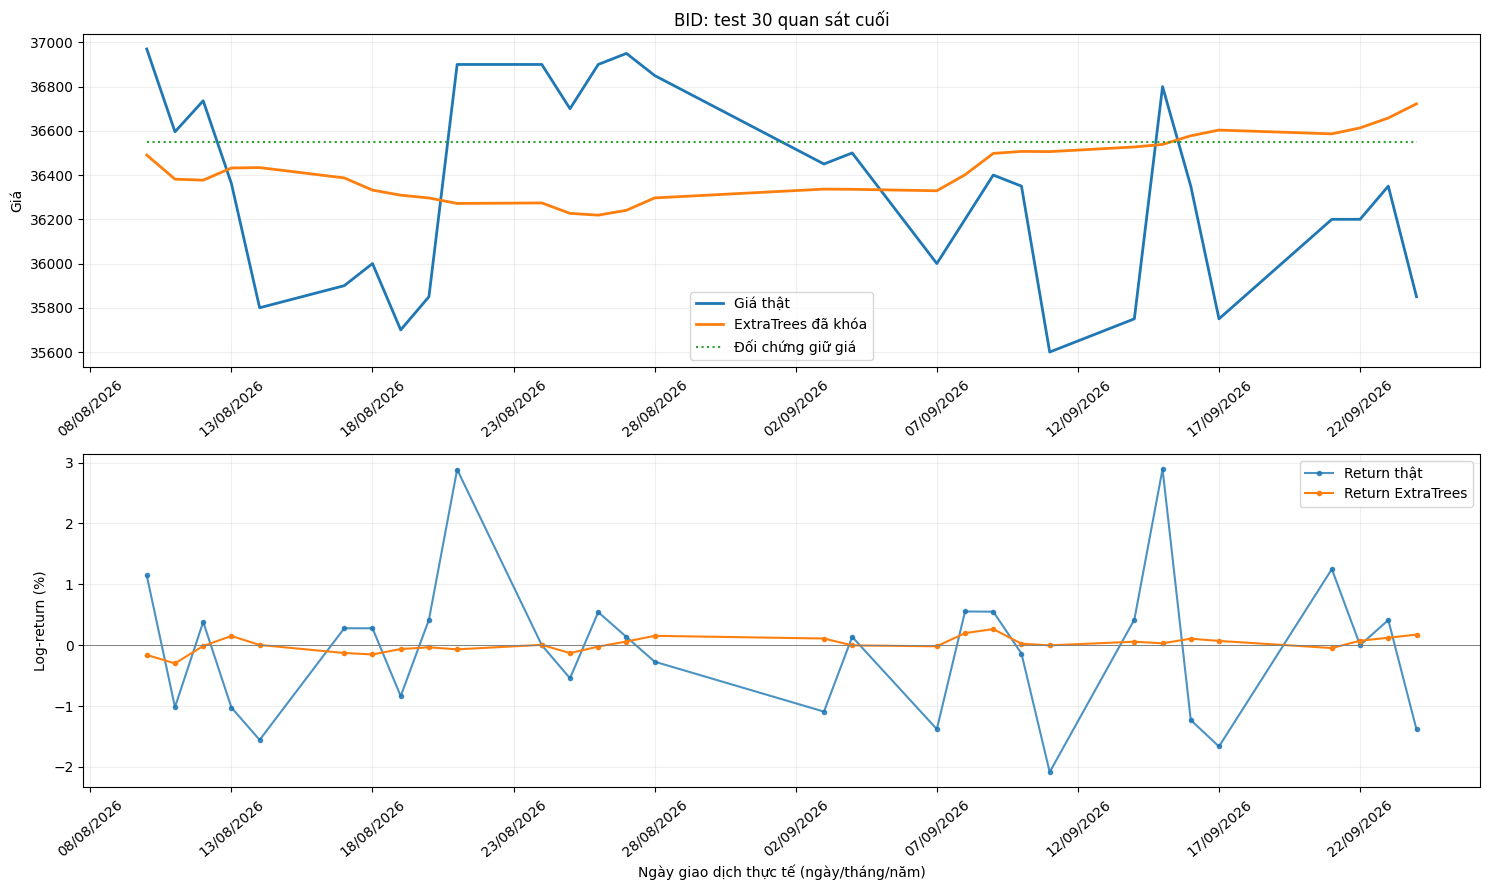

In [27]:
# 12. BIỂU ĐỒ BACKTEST: GIÁ VÀ RETURN TỪNG PHIÊN
fig, axes = plt.subplots(2,1,figsize=(15,9),sharex=True)
c = comparison_df
axes[0].plot(c.ds,c.actual_price,label='Giá thật',lw=2)
axes[0].plot(c.ds,c.forecast_price,label='ExtraTrees đã khóa',lw=2)
axes[0].plot(c.ds,c.baseline_price,':',label='Đối chứng giữ giá')
axes[0].set_title(f'{DATA_LABEL}: test 30 quan sát cuối'); axes[0].set_ylabel('Giá')
axes[1].plot(c.ds,c.actual_return,label='Return thật',marker='.',alpha=.8)
axes[1].plot(c.ds,c.forecast_return,label='Return ExtraTrees',marker='.')
axes[1].axhline(0,color='gray',lw=.7); axes[1].set_ylabel('Log-return (%)')
for ax in axes: ax.legend(); ax.grid(alpha=.2)
import matplotlib.dates as mdates
for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
    ax.tick_params(axis='x',labelbottom=True,labelrotation=40)
axes[1].set_xlabel('Ngày giao dịch thực tế (ngày/tháng/năm)')
plt.tight_layout();plt.show()
# Hai đường đều được dự báo một lần tại đầu cửa sổ, không ghép 30 dự báo 1 ngày cập nhật.

## Đọc kết quả

Đầu ra là return 30 bước do một ExtraTrees dự báo. Giá được tính từ giá cuối và tổng các return đó. Đây là đổi đơn vị đầu ra, không phải mô phỏng hay thêm nhiễu. Return lỗi cùng chiều nhiều phiên vẫn có thể làm giá dự báo lệch dần.

Giảm kích thước lá và bổ sung mục tiêu return giúp cây được phép học nhịp ngắn hạn, nhưng không đảm bảo bắt đúng các nhịp thực tế. Một đường nhiều dao động cũng có thể sai hơn đường mượt. Đọc cả MAPE, return RMSE và đúng chiều; không diễn giải các số nhỏ hơn 50% như một lợi thế dự báo chiều.

Baseline giữ nguyên giá chỉ để so sánh, không được trộn vào output. Kết quả test đã xem trong quá trình phát triển; cần dữ liệu tương lai mới để xác nhận chất lượng ngoài mẫu.

In [28]:
# 13. SAI SỐ THEO HORIZON VÀ KHẢ NĂNG BẮT CHIỀU
horizon_rows=[]
for a,b in [(1,5),(6,10),(11,20),(21,30)]:
    c=comparison_all.loc[comparison_all.horizon.between(a,b)]
    horizon_rows.append({'horizon':f'{a}–{b}',
        'MAPE':100*np.mean(abs(c.forecast_price-c.actual_price)/c.actual_price),
        'Baseline_MAPE':100*np.mean(abs(c.baseline_price-c.actual_price)/c.actual_price),
        'Return_RMSE_pp':np.sqrt(np.mean((c.forecast_return-c.actual_return)**2)),
        'Direction_pct':100*np.mean(direction(c.forecast_return)==direction(c.actual_return))})
horizon_scores=pd.DataFrame(horizon_rows)
display(horizon_scores.round(3))
last_scores=test_scores.loc[(test_scores.origin==test_origins[-1])&(test_scores.model=='ExtraTrees')].iloc[0]
print(f'30 bước cuối: MAPE {last_scores.MAPE:.2f}%, chiều từng bước {last_scores.Daily_direction_pct:.1f}%')

,horizon,MAPE,Baseline_MAPE,Return_RMSE_pp,Direction_pct
0,1–5,1.922,1.764,1.885,33.333
1,6–10,1.062,1.223,1.277,26.667
2,11–20,4.400,4.415,1.411,43.333
3,21–30,5.225,4.748,1.777,43.333


30 bước cuối: MAPE 1.23%, chiều từng bước 36.7%


In [29]:
# 14. CHẨN ĐOÁN TÍN HIỆU — hiển thị, không sửa forecast
r=forecast_path.log_return_pct.to_numpy(float)
print('Cấu hình:',SELECTED)
print('Return dự báo bước 1:',round(r[0],4),'%')
print('Mean |return| dự báo:',round(np.mean(abs(r)),4),'%')
print('Mean |return| 120 quan sát cuối:',round(returns.tail(120).abs().mean(),4),'%')
print('Số bước tăng / giảm / ngang:',int((direction(r)>0).sum()),int((direction(r)<0).sum()),int((direction(r)==0).sum()))
print('Nếu biên độ dự báo thấp, đó là đầu ra model, không được tự khuếch đại để giống giao dịch.')
pred_dir=direction(r)
turns=int(np.sum(pred_dir[:-1]*pred_dir[1:]<0))
print('Số lần đổi dấu tăng/giảm liên tiếp trong forecast:',turns)
print('Chỉ đếm đổi dấu để chẩn đoán, không tối ưu ép số lần đảo chiều.')

Cấu hình: {'train_window': 1512, 'min_leaf': 12, 'target_mode': 'joint', 'half_life': 252, 'robust_limit': 3.0}
Return dự báo bước 1: 0.0642 %
Mean |return| dự báo: 0.3539 %
Mean |return| 120 quan sát cuối: 1.2084 %
Số bước tăng / giảm / ngang: 29 1 0
Nếu biên độ dự báo thấp, đó là đầu ra model, không được tự khuếch đại để giống giao dịch.
Số lần đổi dấu tăng/giảm liên tiếp trong forecast: 2
Chỉ đếm đổi dấu để chẩn đoán, không tối ưu ép số lần đảo chiều.


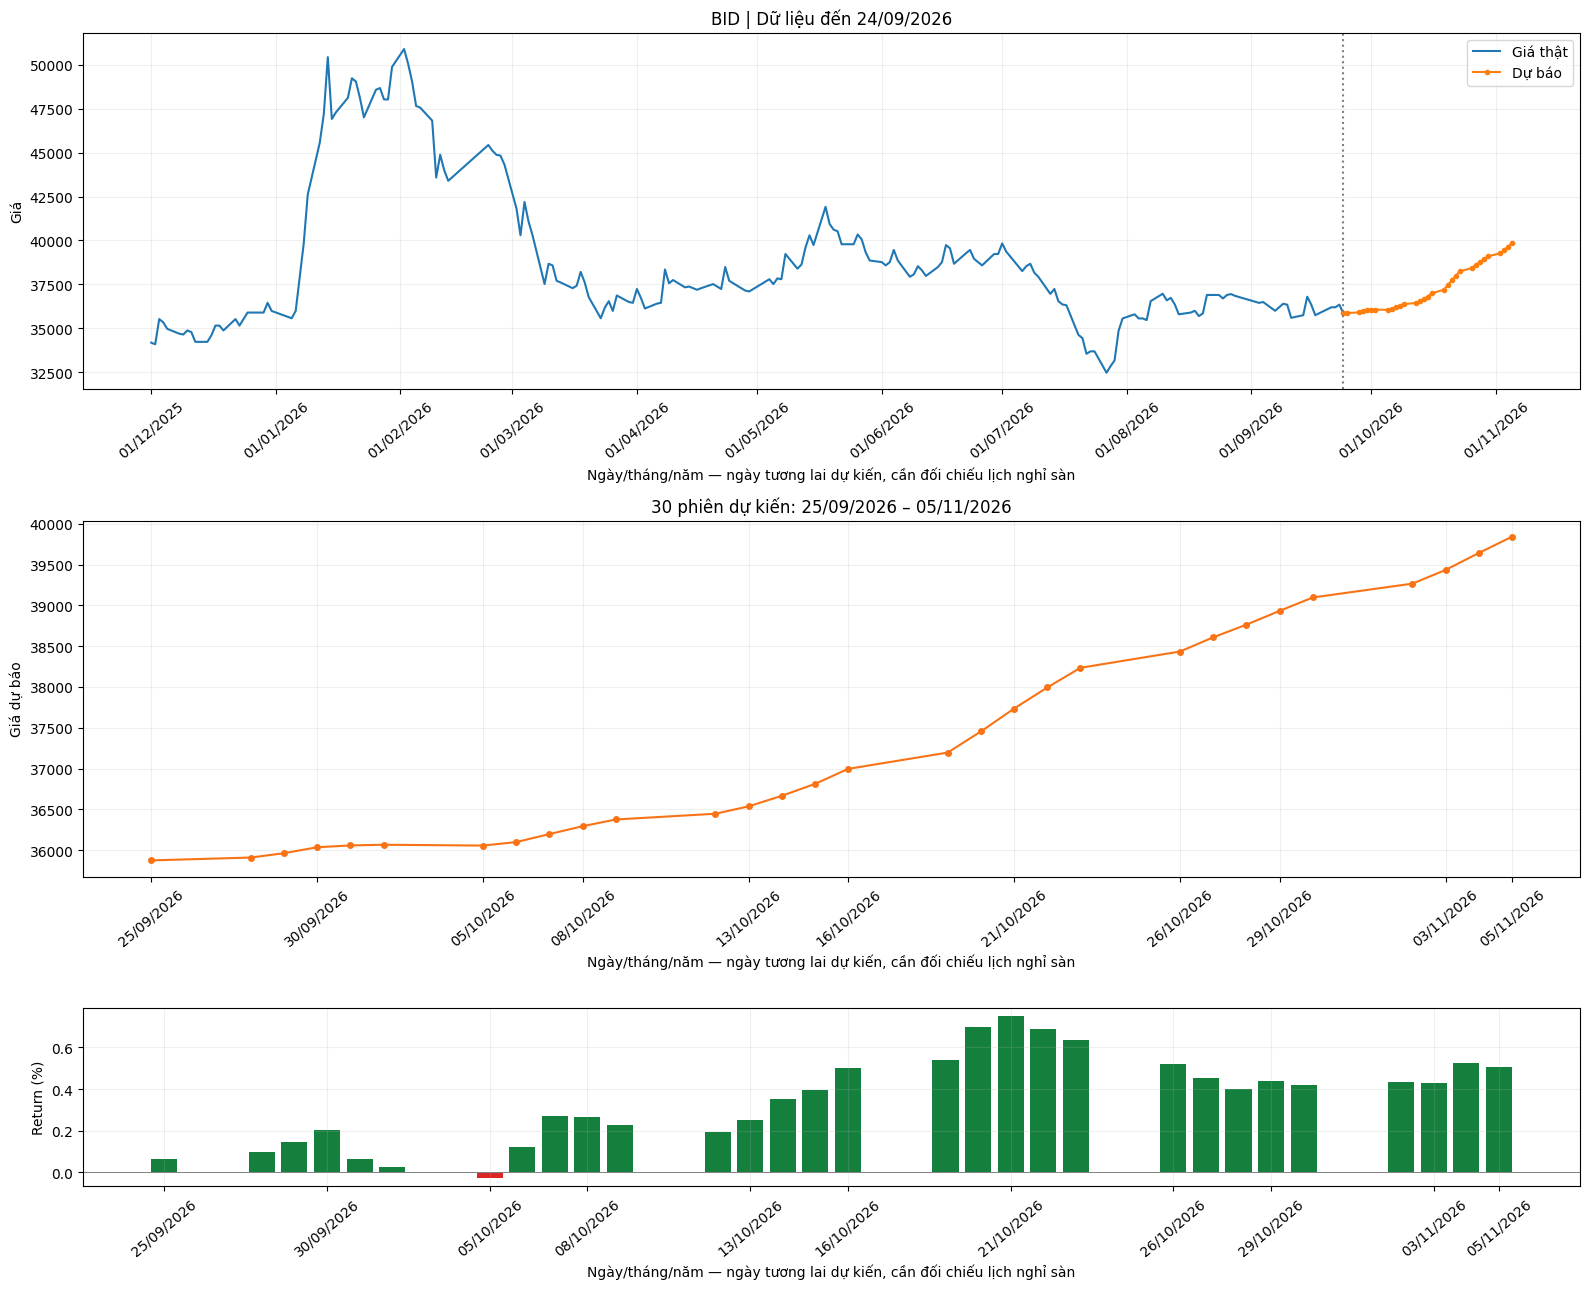

In [30]:
# 15. BIỂU ĐỒ CUỐI — ngày rõ ràng trên từng biểu đồ
import matplotlib.dates as mdates
fig,axes=plt.subplots(3,1,figsize=(16,13),gridspec_kw={'height_ratios':[2,2,1]})
past=df.tail(200)
axes[0].plot(past.ds,past.y,label='Giá thật')
axes[0].plot([df.ds.iloc[-1],*future_dates],np.r_[last_price,future['price']],label='Dự báo',marker='.')
axes[0].axvline(df.ds.iloc[-1],ls=':',color='gray')
axes[0].set_title(f'{DATA_LABEL} | Dữ liệu đến {df.ds.iloc[-1]:%d/%m/%Y}')
axes[0].set_ylabel('Giá'); axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].plot(future_dates,future['price'],marker='o',ms=4,color='#f97316')
axes[1].set_title(f'30 phiên dự kiến: {future_dates[0]:%d/%m/%Y} – {future_dates[-1]:%d/%m/%Y}')
axes[1].set_ylabel('Giá dự báo')
axes[2].bar(future_dates,forecast_path.return_pct,color=np.where(forecast_path.return_pct>=0,'#15803d','#dc2626'))
axes[2].axhline(0,color='gray',lw=.7)
axes[2].set_ylabel('Return (%)')
for ax in axes[1:]:
    ax.set_xticks(future_dates[::3]+([future_dates[-1]] if future_dates[-1]!=future_dates[::3][-1] else []))
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
    ax.tick_params(axis='x',labelrotation=40)
    ax.set_xlabel('Ngày/tháng/năm — ngày tương lai dự kiến, cần đối chiếu lịch nghỉ sàn')
    ax.grid(alpha=.2)
plt.tight_layout();plt.show()


In [31]:
# 16. BẢNG DỰ BÁO VÀ XUẤT KẾT QUẢ
results_30d=forecast_path.copy()
display(results_30d[['session','date_label','weekday','forecast_price','return_pct','change_from_last_pct']].rename(columns={'session':'Phiên','date_label':'Ngày dự kiến','weekday':'Thứ','forecast_price':'Giá dự báo','return_pct':'Thay đổi phiên (%)','change_from_last_pct':'So với giá cuối (%)'}).round(3))
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
results_30d.to_csv(OUTPUT_DIR/'forecast_30_sessions.csv',index=False,date_format='%Y-%m-%d')
validation_df.to_csv(OUTPUT_DIR/'validation_scores.csv',index=False,date_format='%Y-%m-%d')
test_scores.to_csv(OUTPUT_DIR/'test_scores.csv',index=False,date_format='%Y-%m-%d')
comparison_all.to_csv(OUTPUT_DIR/'test_predictions.csv',index=False,date_format='%Y-%m-%d')
horizon_scores.to_csv(OUTPUT_DIR/'horizon_scores.csv',index=False,date_format='%Y-%m-%d')
manifest={'model':MODEL_NAME,'sklearn_version':sklearn.__version__,'selected':SELECTED,'source_sha256':DATA_SHA256,
          'last_date':str(df.ds.iloc[-1].date()),'horizon':HORIZON,
          'selection_weights':SELECTION_WEIGHTS,'model_count':1,
          'validation_origins':val_origins,'test_origins':test_origins}
pd.DataFrame(training_audit).to_csv(OUTPUT_DIR/'training_audit.csv',index=False,date_format='%Y-%m-%d')
(OUTPUT_DIR/'run_config.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
print('Đã xuất kết quả chạy vào:',OUTPUT_DIR.resolve())

,Phiên,Ngày dự kiến,Thứ,Giá dự báo,Thay đổi phiên (%),So với giá cuối (%)
0,1,25/09/2026,Thứ sáu,35873.023,0.064,0.064
1,2,28/09/2026,Thứ hai,35908.287,0.098,0.163
2,3,29/09/2026,Thứ ba,35961.350,0.148,0.311
3,4,30/09/2026,Thứ tư,36034.264,0.203,0.514
4,5,01/10/2026,Thứ năm,36056.723,0.062,0.577
5,6,02/10/2026,Thứ sáu,36065.172,0.023,0.600
6,7,05/10/2026,Thứ hai,36055.016,-0.028,0.572
7,8,06/10/2026,Thứ ba,36097.932,0.119,0.692
8,9,07/10/2026,Thứ tư,36196.123,0.272,0.965
9,10,08/10/2026,Thứ năm,36292.648,0.267,1.235


Đã xuất kết quả chạy vào: /kaggle/working/extratrees_results
